Megan Englert
INFO 5653
Project Part 3


# Section 1: Data and Questions
Corpuses were built manually by creating .txt files in Notepad application.

# Section 2: Cleaning and Preparing the Data

In [1]:
import nltk
import pandas as pd
import sklearn
from sklearn.feature_extraction.text import CountVectorizer
#Convert a collection of raw documents to a matrix of TF-IDF features.
#Equivalent to CountVectorizer but with tf-idf norm
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.tokenize import word_tokenize
## For Stemming
from nltk.stem import PorterStemmer
from nltk.tokenize import sent_tokenize, word_tokenize
import os



In [6]:
df = pd.read_csv("../combinedtextdata.csv").drop("Unnamed: 0", axis=1)
# making new df's in case anything weird happens :)
df1 = df.copy()
df2 = df.copy()
df1

,Source,Source Leaning,type,Combined
0,CNET,Center,news article,What Happens to Student Loans and Financial Ai...
1,Business Insider,Left-Center,news article,I took on almost K in debt to attend an Ivy Le...
2,Time,Not known,news article,Student Loans Still Available After White Hous...
3,Business Insider,Left-Center,news article,Student loans for millions of federal borrower...
4,Yahoo Entertainment,Not known,news article,People Say Their Student Loans Are Being Cance...
...,...,...,...,...
1311,Reddit,Not known,reddit comment,I have some sympathies for children who get in...
1312,Reddit,Not known,reddit comment,I am reading everything three times because no...
1313,Reddit,Not known,reddit comment,I did the same If they live on campus they can...
1314,Reddit,Not known,reddit comment,Youre right I should not have commented on the...


In [42]:
# Creating "Dataframe 1" -- All documents, using to predict type
df1 = df.copy()
df1labels = df1["type"]
contentList = [text for text in df1["Combined"]]

cv1=CountVectorizer(input='content', 
                        stop_words='english',
                        max_features=500)
df1cv = cv1.fit_transform(contentList)
columns = cv1.get_feature_names_out()
print(columns)
matrix1 = pd.DataFrame(df1cv.toarray(), columns = columns)
matrix1 = pd.concat([df1labels, matrix1],axis=1)
matrix1 = matrix1.rename(columns={'type':"LABEL"})
df1 = matrix1.copy().reset_index().drop("index", axis=1)

df1

['able' 'absolutely' 'academic' 'access' 'according' 'actual' 'actually'
 'address' 'administration' 'affect' 'afford' 'affordable' 'agree' 'aid'
 'allowed' 'america' 'american' 'americans' 'amounts' 'apply' 'arent'
 'argument' 'arts' 'attend' 'available' 'average' 'away' 'bad' 'balance'
 'bank' 'bankruptcy' 'based' 'believe' 'benefit' 'benefits' 'best'
 'better' 'biden' 'big' 'biggest' 'billion' 'bills' 'bit' 'board' 'books'
 'borrowers' 'budget' 'building' 'burden' 'business' 'buy' 'buying' 'cap'
 'car' 'care' 'career' 'case' 'cash' 'cc' 'certain' 'change' 'changes'
 'changing' 'charge' 'chars' 'cheaper' 'checks' 'children' 'choice'
 'class' 'classes' 'close' 'college' 'colleges' 'com' 'come' 'comes'
 'comments' 'community' 'companies' 'completely' 'congress' 'continue'
 'control' 'cost' 'costs' 'countries' 'country' 'course' 'courses' 'court'
 'cover' 'covid' 'created' 'credit' 'current' 'currently' 'cut' 'cuts'
 'data' 'daughter' 'day' 'debt' 'debts' 'decades' 'decisions' 'degree'


,LABEL,able,absolutely,academic,access,according,actual,actually,address,administration,...,worse,worth,wouldnt,www,yeah,year,years,yes,young,youre
0,news article,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,news article,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,news article,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,news article,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,news article,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1311,reddit comment,0,0,0,1,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,2
1312,reddit comment,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1313,reddit comment,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1314,reddit comment,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,2,0,0,0,1


In [13]:
# Creating "Dataframe 2" -- News articles 
df2 = df.copy()
df2 = df2[df2["type"] == "news article"]
df2labels = df2["Source Leaning"]
contentList = [text for text in df2["Combined"]]

cv2=CountVectorizer(input='content', 
                        stop_words='english', max_features= 500
                        )
df2cv = cv2.fit_transform(contentList)
columns = cv2.get_feature_names_out()
print(columns)
matrix2 = pd.DataFrame(df2cv.toarray(), columns = columns)
matrix2 = pd.concat([df2labels, matrix2],axis=1)
matrix2 = matrix2.rename(columns={'label':"LABEL"})
limitedterms = matrix2.copy()

df2 = limitedterms.copy()
df2

['abolishes' 'academic' 'access' 'according' 'additional' 'administration'
 'advertising' 'affect' 'affecting' 'afford' 'affordable' 'afp' 'age'
 'agency' 'agreed' 'ai' 'aid' 'al' 'aliens' 'amara' 'american' 'americans'
 'amid' 'amp' 'announced' 'annual' 'appeared' 'apply' 'april' 'arizona'
 'attend' 'average' 'away' 'awlaki' 'bachelor' 'balance' 'bank' 'barroeta'
 'based' 'bello' 'benefit' 'best' 'biden' 'black' 'bloomberg' 'borrower'
 'borrowers' 'briefly' 'budget' 'bureau' 'burned' 'business' 'buyback'
 'called' 'canada' 'card' 'cards' 'catholic' 'center' 'challenge'
 'challenges' 'change' 'changes' 'chaos' 'chars' 'charter' 'child'
 'children' 'choice' 'chopping' 'clear' 'close' 'college' 'colleges'
 'columbia' 'com' 'comments' 'company' 'confirmation' 'considers'
 'constitutional' 'consumer' 'continue' 'continued' 'contract' 'control'
 'controversial' 'cookies' 'cost' 'costs' 'country' 'courses' 'court'
 'courtesy' 'create' 'created' 'credit' 'crisis' 'cut' 'cuts' 'daniels'
 'data

,Source Leaning,abolishes,academic,access,according,additional,administration,advertising,affect,affecting,...,wharton,white,won,wondering,world,worth,year,years,york,young
0,Center,0,0,0,0,0,1,0,1,0,...,0,0,0,1,0,0,0,0,0,0
1,Left-Center,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,Not known,0,0,0,0,0,0,0,0,0,...,0,3,0,2,0,0,0,0,0,0
3,Left-Center,0,0,0,0,0,1,0,0,0,...,0,0,2,0,0,0,0,0,0,0
4,Not known,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,Fake News,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
248,Fake News,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
249,Fake News,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
250,Left-Center,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Section 4: Testing and Training Sets

In [58]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
#import pydotplus 
#import graphviz  
from sklearn.model_selection import train_test_split
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn import tree
from sklearn.metrics import ConfusionMatrixDisplay
testtraindf1 = df1.copy().drop_duplicates()
#testtraindf1 = testtraindf1[testtraindf1["LABEL"] == "news article"]
testtraindf1=testtraindf1.loc[:, ~testtraindf1.columns.duplicated()]

In [60]:

# I'm going to use stratification because it makes for better results :)
articles = testtraindf1[testtraindf1["LABEL"] == "news article"]
comments = testtraindf1[testtraindf1["LABEL"] == "reddit comment"]

positive_train1, positive_test1=train_test_split(articles,test_size=.30)
negative_train1, negative_test1=train_test_split(comments,test_size=.30)
trainDF1 = pd.concat([positive_train1, negative_train1])
testDF1 = pd.concat([positive_test1, negative_test1])
#print("The Training Data is\n", trainDF)
#print("The Testing Data is\n", testDF)

## Now remove the labels from the data - but keep and name the labels
trainLabels1 = trainDF1["LABEL"]

## Remove the label from the dataset itself
trainDF1 = trainDF1.drop(["LABEL"], axis=1)
print(trainDF1)

testLabels1 = testDF1["LABEL"]
## Remove the label from the dataset itself
testDF1 = testDF1.drop(["LABEL"], axis=1)

      able  absolutely  academic  access  according  actual  actually  \
25       0           0         0       0          0       0         0   
217      0           0         0       0          0       0         0   
124      0           0         0       0          0       0         0   
153      0           0         0       0          0       0         0   
166      0           0         0       0          0       0         0   
...    ...         ...       ...     ...        ...     ...       ...   
674      0           0         0       0          0       0         0   
1204     0           0         0       0          0       0         0   
589      0           0         0       0          0       0         0   
728      0           0         0       0          0       0         0   
822      0           0         0       0          0       0         0   

      address  administration  affect  ...  worse  worth  wouldnt  www  yeah  \
25          0               1       0  ... 

In [65]:
testLabels1

171       news article
245       news article
241       news article
205       news article
143       news article
             ...      
934     reddit comment
966     reddit comment
1050    reddit comment
575     reddit comment
1085    reddit comment
Name: LABEL, Length: 385, dtype: object

In [65]:


testtraindf = df2.copy()

# I'm going to use stratification because it makes for better results :)
positives = testtraindf[testtraindf["LABEL"] == "positive"]
negatives = testtraindf[testtraindf["LABEL"] == "negative"]

positive_train, positive_test=train_test_split(positives,test_size=.30)
negative_train, negative_test=train_test_split(negatives,test_size=.30)
trainDF = pd.concat([positive_train, negative_train])
testDF = pd.concat([positive_test, negative_test])
#print("The Training Data is\n", trainDF)
#print("The Testing Data is\n", testDF)

## Now remove the labels from the data - but keep and name the labels
trainLabels = trainDF["LABEL"]

## Remove the label from the dataset itself
trainDF = trainDF.drop(["LABEL"], axis=1)
print(trainDF)

testLabels = testDF["LABEL"]
## Remove the label from the dataset itself
testDF = testDF.drop(["LABEL"], axis=1)
print(testDF)


    abstract  actually  art  beautiful  better  bit  board  card  cards  clue  \
9          0         0    0          0       0    0      1     0      2     1   
7          0         0    1          1       0    1      0     1      2     0   
14         0         0    0          0       0    0      0     0      1     1   
8          0         0    0          0       2    0      0     2      8     0   
2          0         0    0          0       0    1      0     0      0     0   
11         1         0    0          1       0    0      2     0      3     0   
5          1         0    0          0       0    0      0     0      0     1   
3          0         0    0          0       0    3      0     1      2     0   
1          3         2    0          0       2    4      0     0      8     0   
0          0         1    0          0       0    0      0     0      0     0   
19         0         0    0          0       0    0      0     0      0     0   
21         0         0    0 

In [77]:
trainDF2 = trainDF
testDF2 = testDF
trainLabels2 = trainLabels
testLabels2 = testLabels

In [78]:
testDF2

,abstract,actually,art,beautiful,better,bit,board,card,cards,clue,...,tokens,try,trying,understand,use,vision,want,way,weapon,worth
4,0,0,0,1,0,0,0,0,7,1,...,0,0,1,0,1,0,0,0,1,0
10,0,1,0,2,0,0,0,4,2,1,...,0,3,4,0,1,0,0,1,0,0
6,0,0,1,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
13,0,0,2,0,0,0,1,0,1,0,...,0,0,1,0,0,0,0,1,2,0
12,0,0,0,0,0,1,0,0,1,1,...,0,0,0,1,0,0,0,0,1,0
18,0,1,0,1,0,0,0,0,0,1,...,2,0,0,1,1,0,0,2,1,0
16,0,0,1,1,0,0,0,2,3,0,...,0,0,2,0,0,0,0,0,0,0
29,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
17,1,0,2,0,0,0,1,1,1,2,...,0,0,5,0,0,0,0,1,0,0
15,0,1,0,0,0,0,0,3,0,0,...,0,0,1,0,0,0,0,1,0,0


# Section 5 - Multinomial Naive Bayes

The Multinomial NB Model Prediction Probabilities are:
[[0.17  0.83 ]
 [0.04  0.96 ]
 [0.    1.   ]
 [0.    1.   ]
 [0.998 0.002]
 [0.    1.   ]
 [0.886 0.114]
 [0.    1.   ]
 [0.632 0.368]
 [0.364 0.636]]
[[2 3]
 [1 4]]


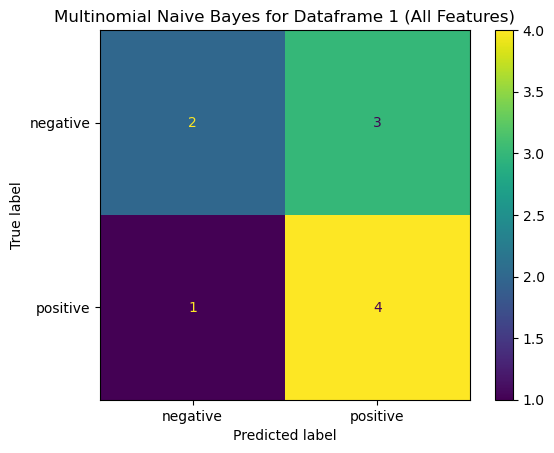

In [85]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
Training_MN = trainDF1.copy()
Testing_MN = testDF1.copy()
Training_MN_Label = trainLabels1.copy()
Testing_MN_Label = testLabels1.copy()

MyMN = MultinomialNB()
My_MN_Model = MyMN.fit(Training_MN, Training_MN_Label)
#print(My_MN_Model)
#print(My_MN_Model.classes_)

## Predict the Testing Data using the model
Predictions_MN=My_MN_Model.predict(Testing_MN)
#print(Predictions_MN)

## Print the actual probabilities
print("The Multinomial NB Model Prediction Probabilities are:")
print(My_MN_Model.predict_proba(Testing_MN).round(3))

## Confusion Matrix
CM_MN = confusion_matrix(Testing_MN_Label, Predictions_MN)
print(CM_MN)
## Pretty confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=CM_MN,display_labels=My_MN_Model.classes_)
disp.plot()
plt.title("Multinomial Naive Bayes for Dataframe 1 (All Features)")
plt.show()


The Multinomial NB Model Prediction Probabilities are:
[[0.041 0.959]
 [0.53  0.47 ]
 [0.262 0.738]
 [0.    1.   ]
 [0.48  0.52 ]
 [1.    0.   ]
 [0.203 0.797]
 [0.446 0.554]
 [0.997 0.003]
 [0.033 0.967]]
[[2 3]
 [1 4]]


<Figure size 640x480 with 0 Axes>

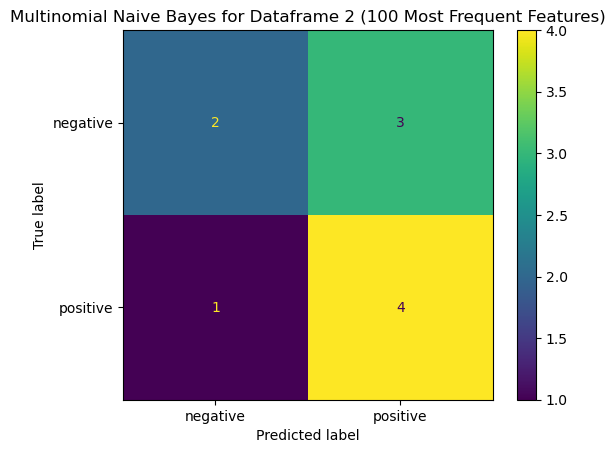

In [88]:
# Clearing the figure because it was giving me exactly the same thing
# and it was freaking me out
plt.clf()

Training_MN = trainDF2.copy()
Testing_MN = testDF2.copy()
Training_MN_Label = trainLabels2.copy()
Testing_MN_Label = testLabels2.copy()

MyMN = MultinomialNB()
My_MN_Model = MyMN.fit(Training_MN, Training_MN_Label)
#print(My_MN_Model)
#print(My_MN_Model.classes_)

## Predict the Testing Data using the model
Predictions_MN=My_MN_Model.predict(Testing_MN)
#print(Predictions_MN)

## Print the actual probabilities
print("The Multinomial NB Model Prediction Probabilities are:")
print(My_MN_Model.predict_proba(Testing_MN).round(3))

## Confusion Matrix
CM_MN = confusion_matrix(Testing_MN_Label, Predictions_MN)
print(CM_MN)
## Pretty confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=CM_MN,display_labels=My_MN_Model.classes_)
disp.plot()
plt.title("Multinomial Naive Bayes for Dataframe 2 (100 Most Frequent Features)")
plt.show()

# Section 6: Decision Trees

In [107]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns

trainDT = trainDF1.copy()
trainDTlabel = trainLabels1.copy()
testDT = testDF1.copy()
testDTlabel = testLabels1.copy()

MyDT_Classifier = DecisionTreeClassifier(criterion="gini",splitter="random")
MyDT_Classifier = MyDT_Classifier.fit(trainDT, trainDTlabel)

FeatureNames=list(trainDT.columns.values) ## get all the feature/variable names
print(FeatureNames)
ClassNames=list(MyDT_Classifier.classes_) ## Get the class names
print(ClassNames)

plt.figure(figsize=(8, 9))
##Tree Plot Option 1
MyPlot=tree.plot_tree(MyDT_Classifier,
                   feature_names=FeatureNames,  
                   class_names=ClassNames,
                   filled=True)
plt.title("Decision Tree for Dataframe 1 (All Features)")
plt.savefig("MyTree1.jpg")
plt.close()

## Use the Tree to make predictions
Prediction=MyDT_Classifier.predict(testDT)
print(Prediction)

Actual_Labels=testDTlabel
print(Actual_Labels)
Predicted_Labels=Prediction

My_Conf_Mat = confusion_matrix(Actual_Labels, Predicted_Labels)
print(My_Conf_Mat)

CM_disp=ConfusionMatrixDisplay(My_Conf_Mat, display_labels=MyDT_Classifier.classes_)
CM_disp.plot()
plt.title("Confusion Matrix for Decision Tree Using Dataframe 1 (All Features)")
plt.savefig("CM.jpg")
plt.close()

['abilities', 'able', 'abstract', 'accessibility', 'according', 'accurate', 'act', 'acting', 'actual', 'actually', 'add', 'added', 'additional', 'adds', 'adjust', 'adult', 'adults', 'advance', 'ages', 'ago', 'agree', 'air', 'allow', 'allowed', 'analyze', 'annoying', 'anomia', 'answers', 'apart', 'apologizing', 'aren', 'art', 'artistic', 'artwork', 'aside', 'asking', 'aspect', 'assigned', 'associate', 'associated', 'associates', 'associations', 'asymmetric', 'attach', 'attempting', 'attractive', 'available', 'average', 'avoid', 'avoids', 'aware', 'away', 'awesome', 'awkward', 'awkwardly', 'bachelorette', 'background', 'backs', 'bad', 'bags', 'balance', 'bananagrams', 'beautiful', 'beautifully', 'beginner', 'beginning', 'best', 'betrayal', 'better', 'biased', 'big', 'bigger', 'biggest', 'binge', 'birthday', 'bit', 'blast', 'board', 'boardgame', 'boils', 'bonus', 'book', 'booklet', 'bored', 'boring', 'bought', 'box', 'brained', 'brains', 'breaking', 'brightly', 'bringing', 'broken', 'brou

In [114]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns

trainDT = trainDF2.copy()
trainDTlabel = trainLabels2.copy()
testDT = testDF2.copy()
testDTlabel = testLabels2.copy()

MyDT_Classifier = DecisionTreeClassifier()
MyDT_Classifier = MyDT_Classifier.fit(trainDT, trainDTlabel)

FeatureNames=list(trainDT.columns.values) ## get all the feature/variable names
print(FeatureNames)
ClassNames=list(MyDT_Classifier.classes_) ## Get the class names
print(ClassNames)

plt.figure(figsize=(8, 9))
##Tree Plot Option 1
MyPlot=tree.plot_tree(MyDT_Classifier,
                   feature_names=FeatureNames,  
                   class_names=ClassNames,
                   filled=True)
plt.title("Decision Tree for Dataframe 2 (100 Features)")
plt.savefig("MyTree2.jpg")
plt.close()

## Use the Tree to make predictions
Prediction=MyDT_Classifier.predict(testDT)
print(Prediction)

Actual_Labels=testDTlabel
print(Actual_Labels)
Predicted_Labels=Prediction

My_Conf_Mat = confusion_matrix(Actual_Labels, Predicted_Labels)
print(My_Conf_Mat)

CM_disp=ConfusionMatrixDisplay(My_Conf_Mat, display_labels=MyDT_Classifier.classes_)
CM_disp.plot()
plt.title("Confusion Matrix for Decision Tree Using Dataframe 2 (100 Features)")
plt.savefig("CM2.jpg")
plt.close()

['abstract', 'actually', 'art', 'beautiful', 'better', 'bit', 'board', 'card', 'cards', 'clue', 'clues', 'concept', 'cooperative', 'daughter', 'definitely', 'different', 'don', 'easy', 'end', 'enjoy', 'experience', 'family', 'feel', 'figure', 'final', 'friends', 'fun', 'game', 'gameplay', 'games', 'ghost', 'good', 'great', 'group', 'guess', 'guesses', 'hard', 'help', 'images', 'instructions', 'interesting', 'just', 'like', 'little', 'location', 'lot', 'love', 'make', 'makes', 'mechanics', 'mysterium', 'mystery', 'need', 'new', 'night', 'old', 'overall', 'partner', 'people', 'perfect', 'person', 'phase', 'pictures', 'pieces', 'place', 'play', 'played', 'player', 'players', 'playing', 'psychic', 'psychics', 'quality', 'read', 'really', 'replayability', 'review', 'reviews', 'right', 'round', 'rules', 'set', 'start', 'super', 'theme', 'thing', 'think', 'thinking', 'time', 'times', 'tokens', 'try', 'trying', 'understand', 'use', 'vision', 'want', 'way', 'weapon', 'worth']
['negative', 'posi

# Section 7 - SVM

In [ ]:
from sklearn.svm import LinearSVC


SVM_Model1=LinearSVC(C=.001)

SVM_Model1.fit(trainDF1, trainLabels1)

print("SVM 1 prediction:\n", SVM_Model1.predict(testDF1))

SVM_matrix = confusion_matrix(testLabels1, SVM_Model1.predict(testDF1))
print("\nThe confusion matrix for Linear SVM is:")
print(SVM_matrix)
print("\n\n")



The confusion matrix for rbf SVM is:
[[3 2]
 [3 2]]





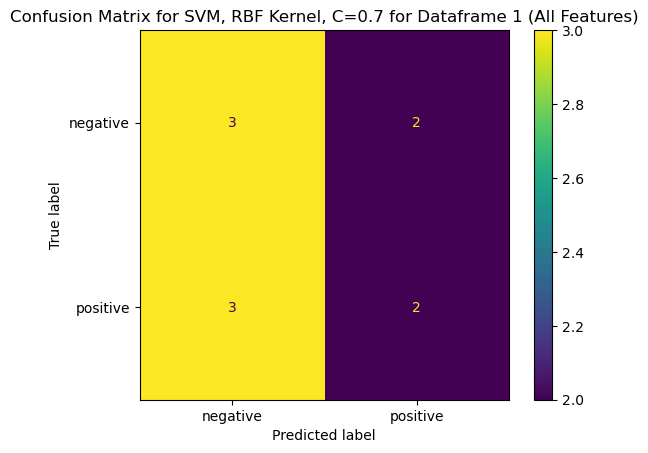

In [125]:
from sklearn.svm import SVC

SVM_Model2=SVC(C=0.7, kernel='rbf', gamma="auto")
SVM_Model2.fit(trainDF1, trainLabels1)

SVM_matrix = confusion_matrix(testLabels1, SVM_Model2.predict(testDF1))
print("\nThe confusion matrix for rbf SVM is:")
print(SVM_matrix)
print("\n\n")

CM_disp=ConfusionMatrixDisplay(SVM_matrix, display_labels=SVM_Model2.classes_)
CM_disp.plot()
plt.title("Confusion Matrix for SVM, RBF Kernel, C=0.7 for Dataframe 1 (All Features)")
plt.show()
plt.close()


The confusion matrix for rbf SVM is:
[[5 0]
 [5 0]]





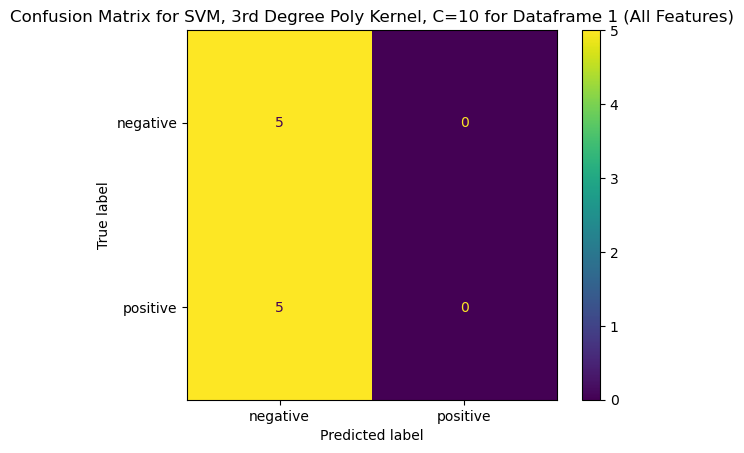

In [159]:
from sklearn.svm import SVC

# LOL the only way I can get it to do anything other than labelling them all as negative
# is to make the degree of the polynomial 1, but the instructions say not linear, so 
# I guess I am not doing that :)

SVM_Model3=SVC(C=10, kernel='poly', degree=3, gamma="auto")
SVM_Model3.fit(trainDF1, trainLabels1)

SVM_matrix = confusion_matrix(testLabels1, SVM_Model3.predict(testDF1))
print("\nThe confusion matrix for rbf SVM is:")
print(SVM_matrix)
print("\n\n")

CM_disp=ConfusionMatrixDisplay(SVM_matrix, display_labels=SVM_Model3.classes_)
CM_disp.plot()
plt.title("Confusion Matrix for SVM, 3rd Degree Poly Kernel, C=10 for Dataframe 1 (All Features)")
plt.show()
plt.close()


The confusion matrix for rbf SVM is:
[[3 2]
 [1 4]]





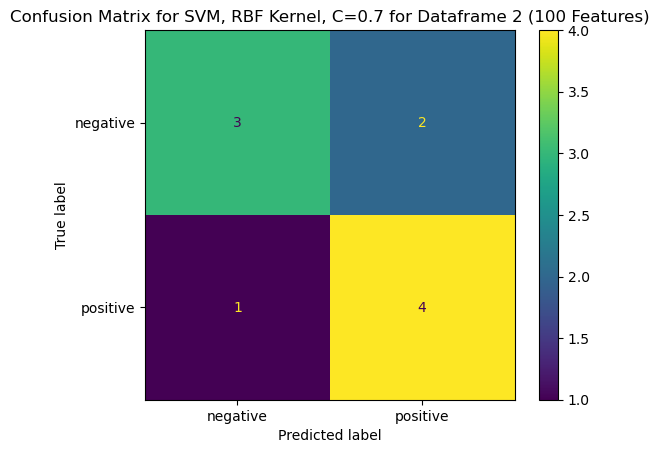

In [141]:
from sklearn.svm import SVC

SVM_Model2=SVC(C=0.7, kernel='rbf', gamma="auto")
SVM_Model2.fit(trainDF2, trainLabels2)

SVM_matrix = confusion_matrix(testLabels2, SVM_Model2.predict(testDF2))
print("\nThe confusion matrix for rbf SVM is:")
print(SVM_matrix)
print("\n\n")

CM_disp=ConfusionMatrixDisplay(SVM_matrix, display_labels=SVM_Model2.classes_)
CM_disp.plot()
plt.title("Confusion Matrix for SVM, RBF Kernel, C=0.7 for Dataframe 2 (100 Features)")
plt.show()
plt.close()


The confusion matrix for rbf SVM is:
[[3 2]
 [1 4]]





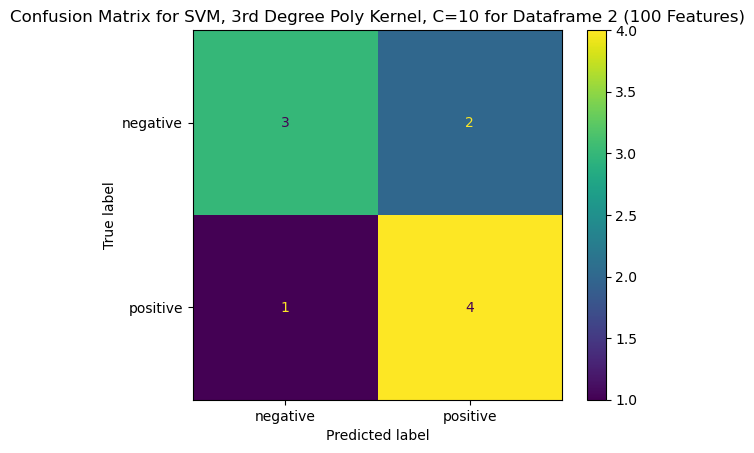

In [157]:
from sklearn.svm import SVC

SVM_Model3=SVC(C=10, kernel='poly', degree=3, gamma="auto")
SVM_Model3.fit(trainDF2, trainLabels2)

SVM_matrix = confusion_matrix(testLabels2, SVM_Model3.predict(testDF2))
print("\nThe confusion matrix for rbf SVM is:")
print(SVM_matrix)
print("\n\n")

CM_disp=ConfusionMatrixDisplay(SVM_matrix, display_labels=SVM_Model3.classes_)
CM_disp.plot()
plt.title("Confusion Matrix for SVM, 3rd Degree Poly Kernel, C=10 for Dataframe 2 (100 Features)")
plt.show()
plt.close()